# 📊 04-visualizations.ipynb
## Análisis del Mercado Laboral Tech en España
**Cliente:** DataTalent Solutions S.L.  
**Objetivo:** Este notebook genera las 10 visualizaciones clave sobre salarios, tecnologías, ciudades y modalidades de trabajo para el informe final.

---
### 🛠️ Instrucciones de uso:
1. Ejecuta las celdas de instalación e importación de librerías.
2. Si tienes tu propio dataset, haz clic en el icono de carpeta (izq.) y súbelo con el nombre `dataset_limpio.csv`. El código lo detectará automáticamente.
3. Si no subes ningún archivo, el notebook generará un **dataset simulado de 400 registros realistas** para que puedas probar todo al instante.


In [1]:
# Instalación de librerías necesarias en el entorno de Colab
!pip install -q pandas numpy matplotlib seaborn

In [3]:
# --------------------------------------------------------------
# 📚 IMPORTACIONES Y CONFIGURACIÓN ESTÉTICA
# ------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo corporativo premium para DataTalent Solutions
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 18,
    "font.family": "sans-serif"
})

# Paleta de colores oficial de la empresa
PALETA_DATATALENT = ["#1A365D", "#2B6CB0", "#4299E1", "#ED8936", "#A0AEC0", "#48BB78"]
sns.set_palette(PALETA_DATATALENT)

In [5]:
# ---------------------------------------------------------------
# 📂 GESTIÓN DE DATOS (Carga de CSV o Simulación automática)
# ---------------------------------------------------------------
def cargar_datos(ruta_csv="dataset_limpio.csv"):
    """Intenta cargar el CSV real. Si no existe, simula un dataset de calidad."""
    if os.path.exists(ruta_csv):
        print(f"✅ ¡Éxito! Cargando datos reales desde: {ruta_csv}")
        return pd.read_csv(ruta_csv)
    else:
        print("⚠️ No se detectó 'dataset_limpio.csv'. Generando dataset de prueba...")
        np.random.seed(42)
        n = 400
        roles = ['Data Analyst', 'Data Scientist', 'Data Engineer', 'BI Analyst', 'Machine Learning Engineer']
        ciudades = ['Madrid', 'Barcelona', 'Remoto', 'Valencia', 'Sevilla', 'Málaga']
        modalidades = ['Presencial', 'Híbrido', 'Remoto']
        seniorities = ['Junior', 'Mid', 'Senior']
        sectores = ['Fintech', 'Consultoría', 'E-commerce', 'Salud', 'Telecomunicaciones', 'Seguros']
        skills = ['Python', 'SQL', 'Power BI', 'AWS', 'Excel', 'Tableau', 'Spark', 'Databricks', 'Docker', 'Git']

        datos = {
            'title': np.random.choice(roles, n, p=[0.35, 0.25, 0.20, 0.12, 0.08]),
            'city': np.random.choice(ciudades, n, p=[0.35, 0.25, 0.15, 0.10, 0.08, 0.07]),
            'salary': np.random.normal(loc=39000, scale=13000, size=n).astype(int),
            'experience_years': np.random.randint(0, 10, size=n),
            'remote_modality': np.random.choice(modalidades, n, p=[0.20, 0.50, 0.30]),
            'seniority': np.random.choice(seniorities, n, p=[0.30, 0.50, 0.20]),
            'sector': np.random.choice(sectores, n, p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]),
            'description': ['Vacante técnica' for _ in range(n)]
        }

        df = pd.DataFrame(datos)

        # Escalar salarios según rango lógico por seniority
        df.loc[df['seniority'] == 'Junior', 'salary'] = df.loc[df['seniority'] == 'Junior', 'salary'].apply(lambda x: max(18000, min(x, 32000)))
        df.loc[df['seniority'] == 'Mid', 'salary'] = df.loc[df['seniority'] == 'Mid', 'salary'].apply(lambda x: max(30000, min(x, 50000)))
        df.loc[df['seniority'] == 'Senior', 'salary'] = df.loc[df['seniority'] == 'Senior', 'salary'].apply(lambda x: max(48000, x))

        # Crear columnas booleanas de habilidades
        for s in skills:
            df[s] = np.random.choice([0, 1], n, p=[0.65, 0.35])

        # Crear columnas comparativas de tecnologías usadas vs deseadas
        techs = ['Python', 'SQL', 'Spark', 'AWS', 'Docker', 'Kubernetes']
        for t in techs:
            df[f'tech_usedₜ'] = np.random.choice([0, 1], n, p=[0.7, 0.3])
            df[f'tech_wantedₜ'] = np.random.choice([0, 1], n, p=[0.6, 0.4])

        return df

def inicializar_sistema():
    """Genera la estructura de carpetas necesaria para exportar los gráficos."""
    os.makedirs('images', exist_ok=True)
    print("📁 Carpeta './images/' lista para almacenar las gráficas exportadas.")

# Ejecutar carga inicial
df = cargar_datos()
inicializar_sistema()


⚠️ No se detectó 'dataset_limpio.csv'. Generando dataset de prueba...
📁 Carpeta './images/' lista para almacenar las gráficas exportadas.


## 📍 Bloque 1: Distribución y Volumen de Vacantes (Gráficos 1, 2 y 3)
En esta sección analizamos de dónde provienen las ofertas, bajo qué modalidades se publican y qué niveles de experiencia/seniority son los más demandados.


/tmp/ipykernel_1591/3917794558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='Blues_r')


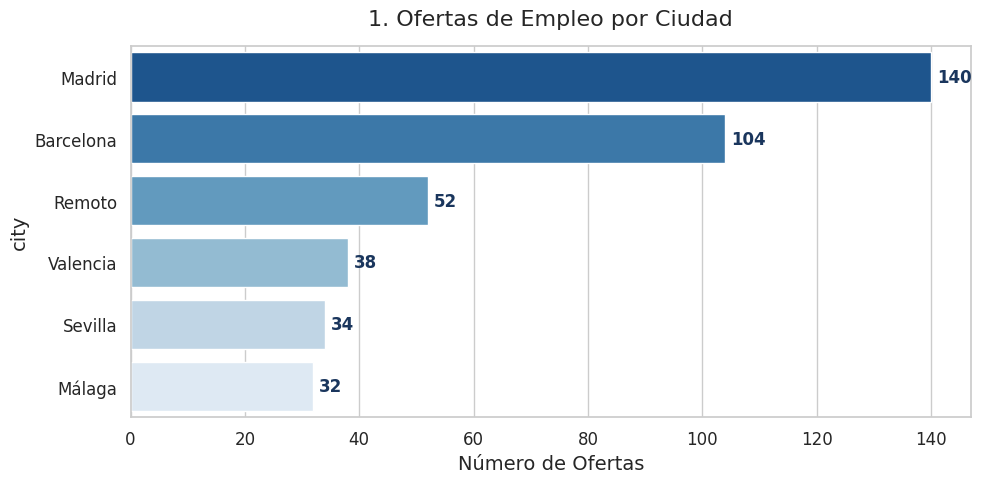

In [7]:
# --- 1️⃣ Ofertas por Ciudad ---
plt.figure(figsize=(10, 5))
city_counts = df['city'].value_counts()
sns.barplot(x=city_counts.values, y=city_counts.index, palette='Blues_r')
plt.title('1. Ofertas de Empleo por Ciudad', pad=15)
plt.xlabel('Número de Ofertas')
for i, v in enumerate(city_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold', color='#1A365D')
plt.tight_layout()
plt.savefig('images/grafico_ofertas_ciudad.png', dpi=300)
plt.show()

# --- 2️⃣ Distribución por Modalidad de Trabajo ---
plt.figure(figsize=(7, 5))
dist_modality = df['remote_modality'].value_counts(normalize=True) * 100
plt.pie(dist_modality.values, labels=dist_modality.index, autopct='%1.1f%%', startangle=90,
        colors=['#2B6CB0', '#4299E1', '#ED8936'], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('2. Distribución por Modalidad de Trabajo', pad=15)
plt.tight_layout()
plt.savefig('images/remoto_vs_presencial.png', dpi=300)
plt.show()

# --- 3️⃣ Distribución por Seniority ---
plt.figure(figsize=(8, 5))
seniority_counts = df['seniority'].value_counts()
sns.barplot(x=seniority_counts.index, y=seniority_counts.values, palette='Greens_r')
plt.title('3. Distribución de Ofertas por Seniority', pad=15)
plt.ylabel('Número de Ofertas')
for i, v in enumerate(seniority_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold', color='#1A365D')
plt.tight_layout()
plt.savefig('images/grafico_distribucion_seniority.png', dpi=300)
plt.show()


## 💵 Bloque 2: Análisis Retributivo y Salarial (Gráficos 4, 5 y 6)
Estudio de la variable económica (`salary`) cruzada con los factores de localización, modalidad y nivel de experiencia.


/tmp/ipykernel_1591/2704884014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seniority', y='salary', data=df, palette='Greens', order=['Junior', 'Mid', 'Senior'])


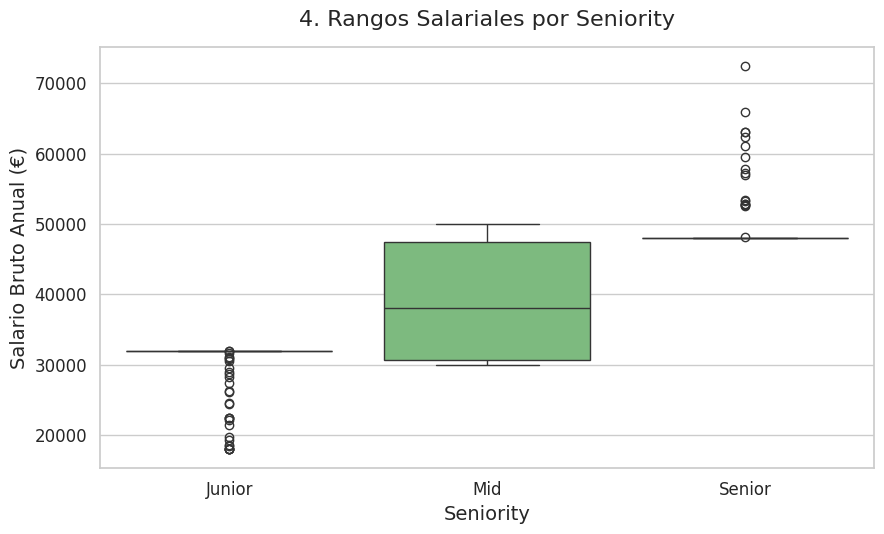

/tmp/ipykernel_1591/2704884014.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='remote_modality', y='salary', data=df, palette='Blues', order=['Presencial', 'Híbrido', 'Remoto'])


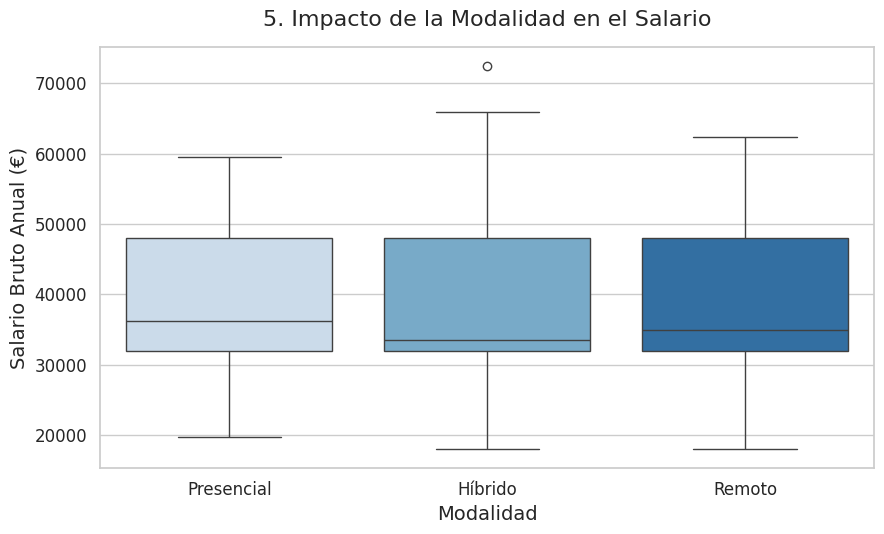

/tmp/ipykernel_1591/2704884014.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sal_ciudad.values, y=sal_ciudad.index, palette='Oranges_r')


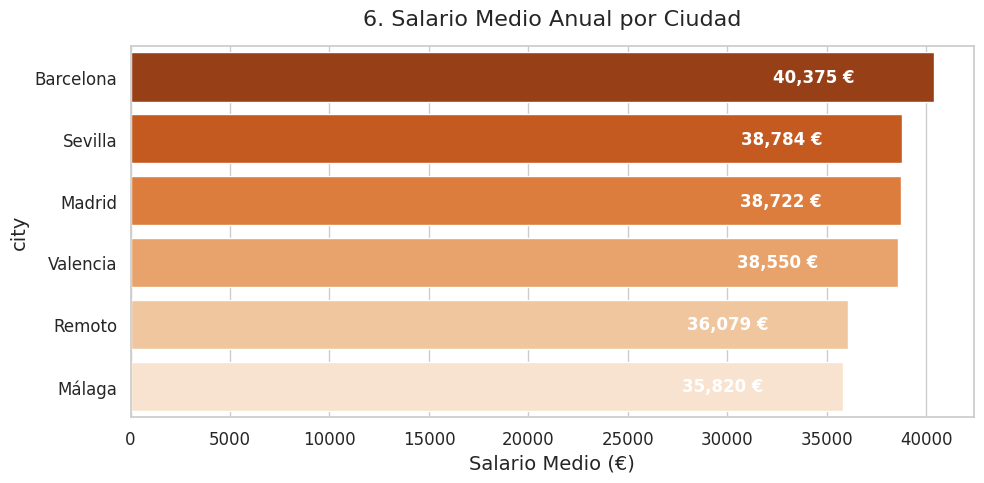

In [8]:
# --- 4️⃣ Salario según Seniority ---
plt.figure(figsize=(9, 5.5))
sns.boxplot(x='seniority', y='salary', data=df, palette='Greens', order=['Junior', 'Mid', 'Senior'])
plt.title('4. Rangos Salariales por Seniority', pad=15)
plt.xlabel('Seniority')
plt.ylabel('Salario Bruto Anual (€)')
plt.tight_layout()
plt.savefig('images/grafico_salario_seniority.png', dpi=300)
plt.show()

# --- 5️⃣ Salario según Modalidad ---
plt.figure(figsize=(9, 5.5))
sns.boxplot(x='remote_modality', y='salary', data=df, palette='Blues', order=['Presencial', 'Híbrido', 'Remoto'])
plt.title('5. Impacto de la Modalidad en el Salario', pad=15)
plt.xlabel('Modalidad')
plt.ylabel('Salario Bruto Anual (€)')
plt.tight_layout()
plt.savefig('images/grafico_salario_modalidad.png', dpi=300)
plt.show()

# --- 6️⃣ Salario Medio por Ciudad ---
plt.figure(figsize=(10, 5))
sal_ciudad = df.groupby('city')['salary'].mean().sort_values(ascending=False)
sns.barplot(x=sal_ciudad.values, y=sal_ciudad.index, palette='Oranges_r')
plt.title('6. Salario Medio Anual por Ciudad', pad=15)
plt.xlabel('Salario Medio (€)')
for i, v in enumerate(sal_ciudad.values):
    plt.text(v - 4000, i, f"{v:,.0f} €", va='center', ha='right', fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('images/grafico_salario_ciudad.png', dpi=300)
plt.show()


## 🚀 Bloque 3: Stack Tecnológico, Demanda e Impacto de Sectores (Gráficos 7, 8, 9 y 10)
Análisis avanzado de los lenguajes y herramientas requeridas, la brecha entre herramientas actuales/deseadas, y distribución por sectores de negocio.


/tmp/ipykernel_1591/1126495626.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct_skills.values, y=pct_skills.index, palette='Blues_r')


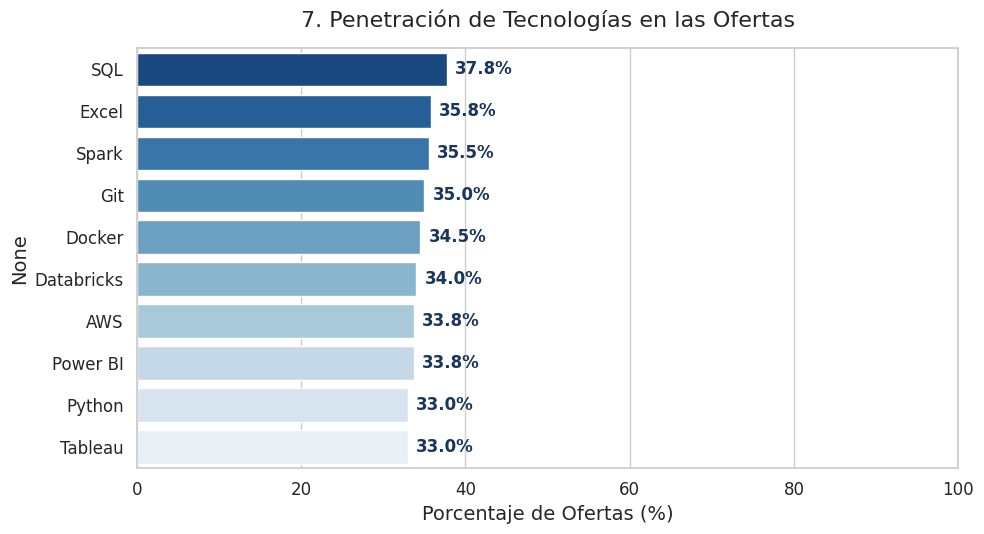

/tmp/ipykernel_1591/1126495626.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(salarios_tech.values()), y=list(salarios_tech.keys()), palette='Purples_r')


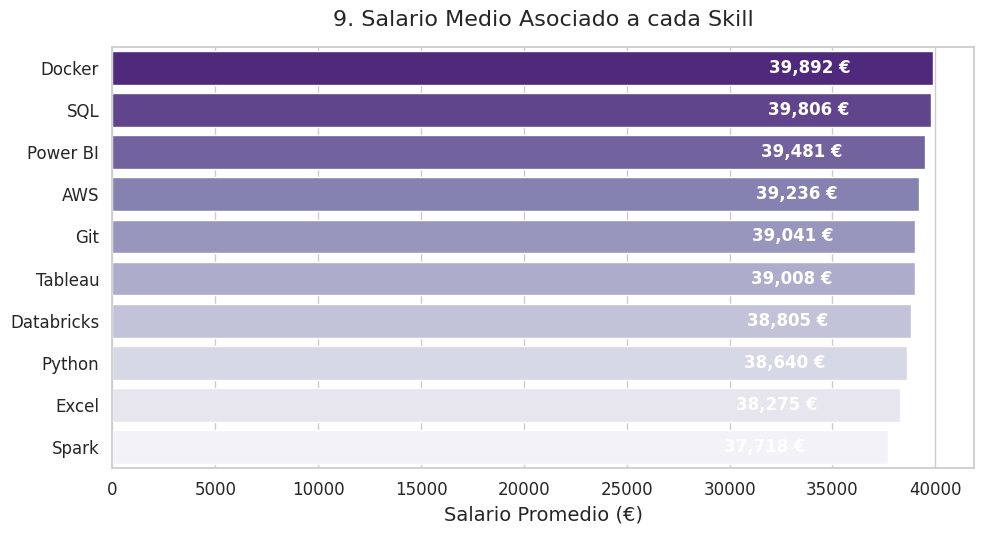

/tmp/ipykernel_1591/1126495626.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sectores.values, y=sectores.index, palette='YlGnBu_r')


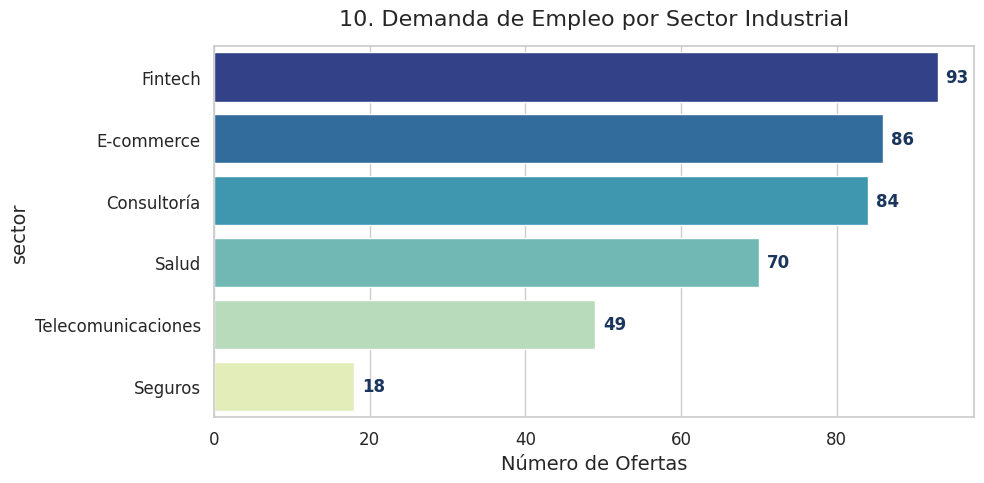


🎉 ¡Éxito! Las 10 visualizaciones se han generado e impreso correctamente.
📁 Puedes descargarlas en alta calidad (300 DPI) desde la carpeta 'images/' a la izquierda.


In [9]:
# --- 7️⃣ Top Tecnologías Demandadas ---
skills_lista = ['Python', 'SQL', 'Power BI', 'AWS', 'Excel', 'Tableau', 'Spark', 'Databricks', 'Docker', 'Git']
presentes = [s for s in skills_lista if s in df.columns]

plt.figure(figsize=(10, 5.5))
pct_skills = (df[presentes].sum() / len(df) * 100).sort_values(ascending=False)
sns.barplot(x=pct_skills.values, y=pct_skills.index, palette='Blues_r')
plt.title('7. Penetración de Tecnologías en las Ofertas', pad=15)
plt.xlabel('Porcentaje de Ofertas (%)')
plt.xlim(0, 100)
for i, v in enumerate(pct_skills.values):
    plt.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold', color='#1A365D')
plt.tight_layout()
plt.savefig('images/grafico_skills.png', dpi=300)
plt.show()

# --- 8️⃣ Comparativa Used vs Wanted ---
used_cols = [c for c in df.columns if c.startswith('tech_used_')]
if len(used_cols) > 0:
    tech_names = [c.replace('tech_used_', '') for c in used_cols]
    pct_used = [(df[f'tech_usedₜ'].sum() / len(df)) * 100 for t in tech_names]
    pct_wanted = [(df[f'tech_wantedₜ'].sum() / len(df)) * 100 for t in tech_names]

    comparativo = pd.DataFrame({
        'Tecnología': tech_names * 2,
        'Porcentaje (%)': pct_used + pct_wanted,
        'Tipo': ['Uso Actual'] * len(tech_names) + ['Deseada (Wanted)'] * len(tech_names)
    })

    plt.figure(figsize=(11, 5.5))
    sns.barplot(x='Tecnología', y='Porcentaje (%)', hue='Tipo', data=comparativo, palette=['#2B6CB0', '#ED8936'])
    plt.title('8. Tecnologías: Uso Actual vs. Deseadas', pad=15)
    plt.ylim(0, 100)
    plt.legend(title='Estado')
    plt.tight_layout()
    plt.savefig('images/grafico_used_vs_wanted.png', dpi=300)
    plt.show()

# --- 9️⃣ Salario Medio según Stack Tecnológico ---
salarios_tech = {}
for s in presentes:
    avg = df[df[s] == 1]['salary'].mean()
    if not np.isnan(avg):
        salarios_tech[s] = avg
salarios_tech = dict(sorted(salarios_tech.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5.5))
sns.barplot(x=list(salarios_tech.values()), y=list(salarios_tech.keys()), palette='Purples_r')
plt.title('9. Salario Medio Asociado a cada Skill', pad=15)
plt.xlabel('Salario Promedio (€)')
for i, v in enumerate(salarios_tech.values()):
    plt.text(v - 4000, i, f"{v:,.0f} €", va='center', ha='right', fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('images/grafico_salario_tecnologia.png', dpi=300)
plt.show()

# --- 🔟 Ofertas por Sector Industrial ---
if 'sector' in df.columns:
    plt.figure(figsize=(10, 5))
    sectores = df['sector'].value_counts()
    sns.barplot(x=sectores.values, y=sectores.index, palette='YlGnBu_r')
    plt.title('10. Demanda de Empleo por Sector Industrial', pad=15)
    plt.xlabel('Número de Ofertas')
    for i, v in enumerate(sectores.values):
        plt.text(v + 1, i, str(v), va='center', fontweight='bold', color='#1A365D')
    plt.tight_layout()
    plt.savefig('images/grafico_ofertas_sector.png', dpi=300)
    plt.show()

print("\n🎉 ¡Éxito! Las 10 visualizaciones se han generado e impreso correctamente.")
print("📁 Puedes descargarlas en alta calidad (300 DPI) desde la carpeta 'images/' a la izquierda.")
